<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/Tarefa011_topicos3e4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Modelo de Bernoulli

### Explicação Conceitual
O **Modelo de Bernoulli** é um modelo de probabilidade discreta que descreve um experimento aleatório composto por uma única observação com exatamente **dois resultados possíveis e mutuamente exclusivos**: a ocorrência do evento de interesse (definido como **sucesso**) ou a sua não ocorrência (definida como **fracasso**).

### Identificação dos Parâmetros no Exemplo Escolhido
Usando a análise com a tartaruga-verde (*Chelonia mydas*) e a presença de fibropapilomatose, podemos definir:

* **Sucesso (X = 1):** A tartaruga-verde apresenta fibropapilomatose.
* **Fracasso (X = 0):** A tartaruga-verde NÃO apresenta fibropapilomatose.
* **Probabilidade de Sucesso (p):** **p = 0,1541** (ou 15,41%, de acordo com os dados do Projeto TAMAR).
* **Probabilidade de Fracasso (q):** q =  1 - p
=  1 - 0,1541
=  0,8459 (ou 84,59%).
* **Variável Aleatória (\(X\)):** Presença de fibropapilomatose no indivíduo, onde \(X \sim \text{Bernoulli}(p = 0{,}1541)\) e \(X \in \{0, 1\}\).

In [1]:
import numpy as np
import scipy.stats as stats

# Parâmetro de probabilidade de sucesso (presença de fibropapilomatose)
p = 0.1541

# Definição da variável aleatória de Bernoulli
X_bernoulli = stats.bernoulli(p)

# Probabilidades teóricas dos dois resultados possíveis
prob_fracasso = X_bernoulli.pmf(0)  # P(X = 0)
prob_sucesso = X_bernoulli.pmf(1)  # P(X = 1)

# Média e Variância teóricas
media_bernoulli = X_bernoulli.mean()
variancia_bernoulli = X_bernoulli.var()

print('--- MODELO DE BERNOULLI ---')
print(f'P(X = 0) [Sem Doença / Fracasso]: {prob_fracasso:.4f}')
print(f'P(X = 1) [Com Doença / Sucesso]: {prob_sucesso:.4f}')
print(f'Média E[X]: {media_bernoulli:.4f}')
print(f'Variância Var(X): {variancia_bernoulli:.4f}')

# Simulação empírica de 1.000 observações individuais
np.random.seed(42)
simulacao = X_bernoulli.rvs(size=1000)

casos_doentes = np.sum(simulacao == 1)
casos_sadios = np.sum(simulacao == 0)

print('\n--- RESULTADO DA SIMULAÇÃO (1.000 INDIVÍDUOS) ---')
print(f'Tartarugas com fibropapilomatose (X = 1): {casos_doentes}')
print(f'Tartarugas saudáveis (X = 0): {casos_sadios}')

--- MODELO DE BERNOULLI ---
P(X = 0) [Sem Doença / Fracasso]: 0.8459
P(X = 1) [Com Doença / Sucesso]: 0.1541
Média E[X]: 0.1541
Variância Var(X): 0.1304

--- RESULTADO DA SIMULAÇÃO (1.000 INDIVÍDUOS) ---
Tartarugas com fibropapilomatose (X = 1): 156
Tartarugas saudáveis (X = 0): 844


### Interpretação da Saída no Contexto Biológico
A variável aleatória de Bernoulli assume o valor **1** para indicar que a tartaruga-verde apresenta a lesão tumoral por fibropapilomatose e o valor **0** para indicar que o indivíduo está saudável. A probabilidade **p = 0,1541** representa a chance de selecionar aleatoriamente uma tartaruga doente nas condições epidemiológicas monitoradas pelo estudo.

## 4. Modelo Binomial

### Explicação Conceitual e Condições do Modelo
O **Modelo Binomial** descreve o **número total de sucessos** obtidos em um número fixo \(n\) de ensaios de Bernoulli independentes e identicamente distribuídos.

Para a aplicação adequada do modelo no cenário biológico, devem ser atendidas as seguintes condições:
1. **Número fixo de observações (n):** O tamanho da amostra é determinado previamente (ex.: n = 20 tartarugas).
2. **Dois resultados possíveis:** Cada indivíduo é classificado apenas como doente (sucesso) ou saudável (fracasso).
3. **Probabilidade de sucesso constante (p):** A chance de um indivíduo apresentar a doença é idêntica para todas as observações (p = 0,1541).
4. **Independência entre observações:** A presença de tumores em uma tartaruga não altera a probabilidade das demais apresentarem a doença.
5. **Variável aleatória de interesse (Y):** Representa o número total de indivíduos com fibropapilomatose na amostra.

A função de probabilidade é dada por:

$$P(Y = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

--- MODELO BINOMIAL (n = 20, p = 0.1541) ---
Número médio esperado de tartarugas doentes E[Y]: 3.08
Variância esperada Var(Y): 2.61

P(Y = 0) [Nenhuma doente na amostra]: 0.0352 (3.52%)
P(Y = 3) [Exatamente 3 doentes na amostra]: 0.2425 (24.25%)
P(Y <= 3) [No máximo 3 doentes na amostra]: 0.6278 (62.78%)


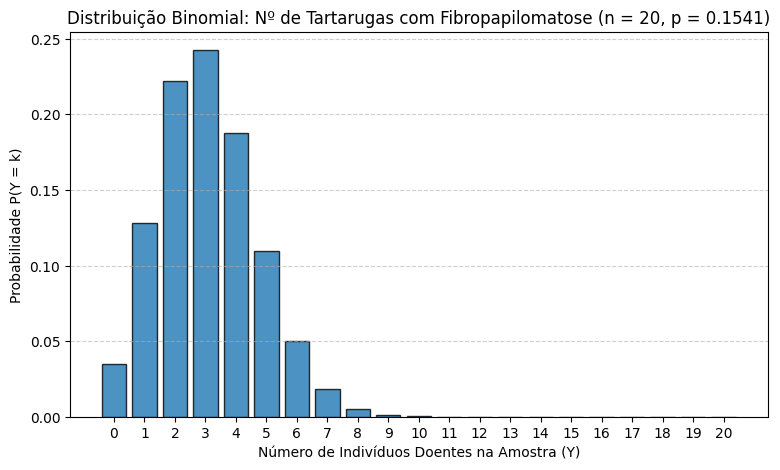

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Parâmetros da amostragem
n = 20  # Tamanho da amostra de tartarugas
p = 0.1541  # Prevalência da doença

# Definição do modelo Binomial
Y_binomial = stats.binom(n, p)

# Média esperada e Variância
media_esperada = Y_binomial.mean()  # E[Y] = n * p
variancia_esperada = Y_binomial.var()  # Var(Y) = n * p * (1 - p)

print('--- MODELO BINOMIAL (n = 20, p = 0.1541) ---')
print(
    f'Número médio esperado de tartarugas doentes E[Y]: {media_esperada:.2f}'
)
print(f'Variância esperada Var(Y): {variancia_esperada:.2f}')

# Cálculos de probabilidades pontuais e acumuladas
prob_0 = Y_binomial.pmf(0)
prob_3 = Y_binomial.pmf(3)
prob_ate_3 = Y_binomial.cdf(3)  # P(Y <= 3)

print(f'\nP(Y = 0) [Nenhuma doente na amostra]: {prob_0:.4f} ({prob_0*100:.2f}%)')
print(
    f'P(Y = 3) [Exatamente 3 doentes na amostra]: {prob_3:.4f} ({prob_3*100:.2f}%)'
)
print(
    f'P(Y <= 3) [No máximo 3 doentes na amostra]: {prob_ate_3:.4f} ({prob_ate_3*100:.2f}%)'
)

# Gráfico da Distribuição de Probabilidade
k_valores = np.arange(0, n + 1)
probabilidades = Y_binomial.pmf(k_valores)

plt.figure(figsize=(9, 5))
plt.bar(k_valores, probabilidades, color='#1f77b4', edgecolor='black', alpha=0.8)
plt.title(
    'Distribuição Binomial: Nº de Tartarugas com Fibropapilomatose (n = 20, p = 0.1541)'
)
plt.xlabel('Número de Indivíduos Doentes na Amostra (Y)')
plt.ylabel('Probabilidade P(Y = k)')
plt.xticks(k_valores)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Discussão sobre a Adequação das Suposições ao Cenário Biológico

1. **Interpretação dos Resultados:** Em um grupo amostrado de 20 tartarugas-verdes, espera-se encontrar em média 3,08 indivíduos com fibropapilomatose. A probabilidade de encontrar no máximo 3 indivíduos doentes na amostra é de 62,73%.
2. **Avaliação da Suposição de Independência:** Na prática de campo, se as 20 tartarugas forem capturadas juntas na mesma área de alimentação altamente poluída, a ocorrência de fibropapilomatose pode estar correlacionada entre elas (devido ao contágio viral ou estresse ambiental compartilhado). Isso violaria levemente a premissa de independência. Para contornar essa limitação, o protocolo de amostragem deve priorizar a aleatoriedade espacial e temporal.
3. **Estabilidade da Probabilidade (p):** Assumiu-se \(p\) constante 15,41%. Contudo, a prevalência pode oscilar conforme a classe etária das tartarugas (juvenis costumam apresentar maior prevalência do que adultos). O modelo se mantém válido desde que a amostragem seja restrita a uma mesma classe populacional.